# 🎙️ BaltiVoice ASR
### Fine-tuning Whisper for Balti Language — A Low-Resource ASR System

---

[![Dataset](https://img.shields.io/badge/🤗%20Dataset-baltivoice--asr-blue)](https://huggingface.co/datasets/mohdali1/baltivoice-asr)
[![Model](https://img.shields.io/badge/🤗%20Model-whisper--small--balti-green)](https://huggingface.co/mohdali1/whisper-small-balti)
[![Demo](https://img.shields.io/badge/🤗%20Demo-baltivoice--demo-orange)](https://huggingface.co/spaces/mohdali1/baltivoice-demo)

**Balti (بلتی)** is a critically low-resource Tibetic language spoken by ~300,000 people in Gilgit-Baltistan, Pakistan. This notebook presents the first publicly available ASR system for Balti, fine-tuned on 16.8 hours of validated speech data.

---

## 📋 Table of Contents
1. [Environment Setup](#setup)
2. [Dataset Loading & Audit](#dataset)
3. [Dataset Statistics & Visualizations](#stats)
4. [Sample Sentences](#samples)
5. [Audio Duration Analysis](#duration)
6. [Train / Dev Split](#split)
7. [Model & Preprocessing Setup](#model)
8. [Fine-tuning Whisper](#training)
9. [Training Results](#results)
10. [Push to HuggingFace Hub](#push)

---
## 1. Environment Setup
Mount Google Drive, extract the audio dataset, and install required packages.

In [1]:
# Install all required packages
!pip install transformers datasets accelerate evaluate jiwer librosa soundfile scikit-learn matplotlib seaborn -q
print('✅ Packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.7 MB/s eta 0:00:00
✅ Packages installed


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive mounted')

Mounted at /content/drive
✅ Drive mounted


In [4]:
import zipfile, os

ZIP_PATH   = '/content/drive/MyDrive/Balti Voice Model/wavs.zip'
EXTRACT_TO = '/content/baltivoice_clips'
os.makedirs(EXTRACT_TO, exist_ok=True)

if not os.path.exists(f'{EXTRACT_TO}/wavs'):
    print('Unzipping audio files...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO)

wav_count = len(os.listdir(f'{EXTRACT_TO}/wavs'))
print(f'✅ {wav_count:,} WAV files ready')

Unzipping audio files...
✅ 10,060 WAV files ready


In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import torch
from tqdm import tqdm
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Paths ────────────────────────────────────────────────────
DATASET_ROOT = '/content/drive/MyDrive/Balti Voice Model'
CLIPS_BASE   = '/content/baltivoice_clips'
TRAIN_LIST   = f'{CLIPS_BASE}/train_list.txt'
OUTPUT_DIR   = f'{DATASET_ROOT}/baltivoice_processed'
NEW_TOKEN    = 'hf_**********************'   # ← your HuggingFace token

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── GPU check ────────────────────────────────────────────────
gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f'✅ Config ready | Device: {gpu}')

✅ Config ready | Device: Tesla T4


---
## 2. Dataset Loading & Audit

The dataset is stored as `train_list.txt` — a pipe-separated file where each line is:
```
wavs/common_voice_bft_XXXXXXX.wav | بلتی جملہ
```
We load it into a DataFrame and verify all audio files exist on disk.

In [7]:
# Load train_list.txt into a DataFrame
rows = []
with open(TRAIN_LIST) as f:
    for line in f:
        line = line.strip()
        if '|' not in line:
            continue
        path, sentence = line.split('|', 1)
        rows.append({'path': path.strip(), 'sentence': sentence.strip()})

df = pd.DataFrame(rows)
df['full_path']  = df['path'].apply(lambda p: os.path.join(CLIPS_BASE, p))
df['word_count'] = df['sentence'].str.split().str.len()
df['char_len']   = df['sentence'].str.len()

print(f'Total samples loaded : {len(df):,}')
print(f'Columns              : {list(df.columns)}')
print(f'\nFirst 5 entries:')
df[['path', 'sentence']].head()

Total samples loaded : 10,060
Columns              : ['path', 'sentence', 'full_path', 'word_count', 'char_len']

First 5 entries:


,path,sentence
0,wavs/common_voice_bft_42287284.wav,بوا لہ سلام بے اِنپا سلام سہ مہ بیاس
1,wavs/common_voice_bft_41914448.wav,یونی خسمینگ دوکسے دوکسے ہلتسنارے گو ٹوق بیاسید۔
2,wavs/common_voice_bft_41847282.wav,رگالوکھسی اونگ چھولو ہرژید نہ، رگانو جق چک نان...
3,wavs/common_voice_bft_42171562.wav,دو زیربا نہ کھو سی زیرس، ”لے مِلی اتا ن٘ا غزون...
4,wavs/common_voice_bft_41848550.wav,رگالوکھسی جوئی نالا زدرونگ ہیاب فانین چی


In [9]:
# Verify all audio files exist on disk
missing, found = [], []

for _, row in tqdm(df.iterrows(), total=len(df), desc='Verifying audio files'):
    (found if os.path.exists(row['full_path']) else missing).append(row['path'])

print(f'\n✅ Found   : {len(found):,}')
print(f'❌ Missing  : {len(missing):,}')

if missing:
    df = df[~df['path'].isin(missing)].reset_index(drop=True)
    print(f'Dataset after cleanup: {len(df):,}')
else:
    print('All audio files verified — no missing files')

Verifying audio files: 100%|██████████| 10060/10060 [00:00<00:00, 23321.59it/s]


✅ Found   : 10,060
❌ Missing  : 0
All audio files verified — no missing files


---
## 3. Dataset Statistics & Visualizations

We analyse the distribution of sentence lengths (words and characters) across the full dataset.

In [10]:
# Summary statistics
print('=' * 50)
print('       BALTIVOICE DATASET SUMMARY')
print('=' * 50)
print(f'  Total samples          : {len(df):,}')
print(f'  Unique sentences       : {df["sentence"].nunique():,}')
print(f'  Avg words per sentence : {df["word_count"].mean():.2f}')
print(f'  Avg chars per sentence : {df["char_len"].mean():.2f}')
print(f'  Min words              : {df["word_count"].min()}')
print(f'  Max words              : {df["word_count"].max()}')
print('=' * 50)
print('\nDetailed Stats:')
df[['word_count', 'char_len']].describe().round(2)

       BALTIVOICE DATASET SUMMARY
  Total samples          : 10,060
  Unique sentences       : 5,850
  Avg words per sentence : 10.12
  Avg chars per sentence : 48.80
  Min words              : 1
  Max words              : 48

Detailed Stats:


,word_count,char_len
count,10060.00,10060.00
mean,10.12,48.80
std,4.74,23.29
min,1.00,4.00
25%,7.00,33.00
50%,9.00,45.00
75%,12.00,59.00
max,48.00,252.00


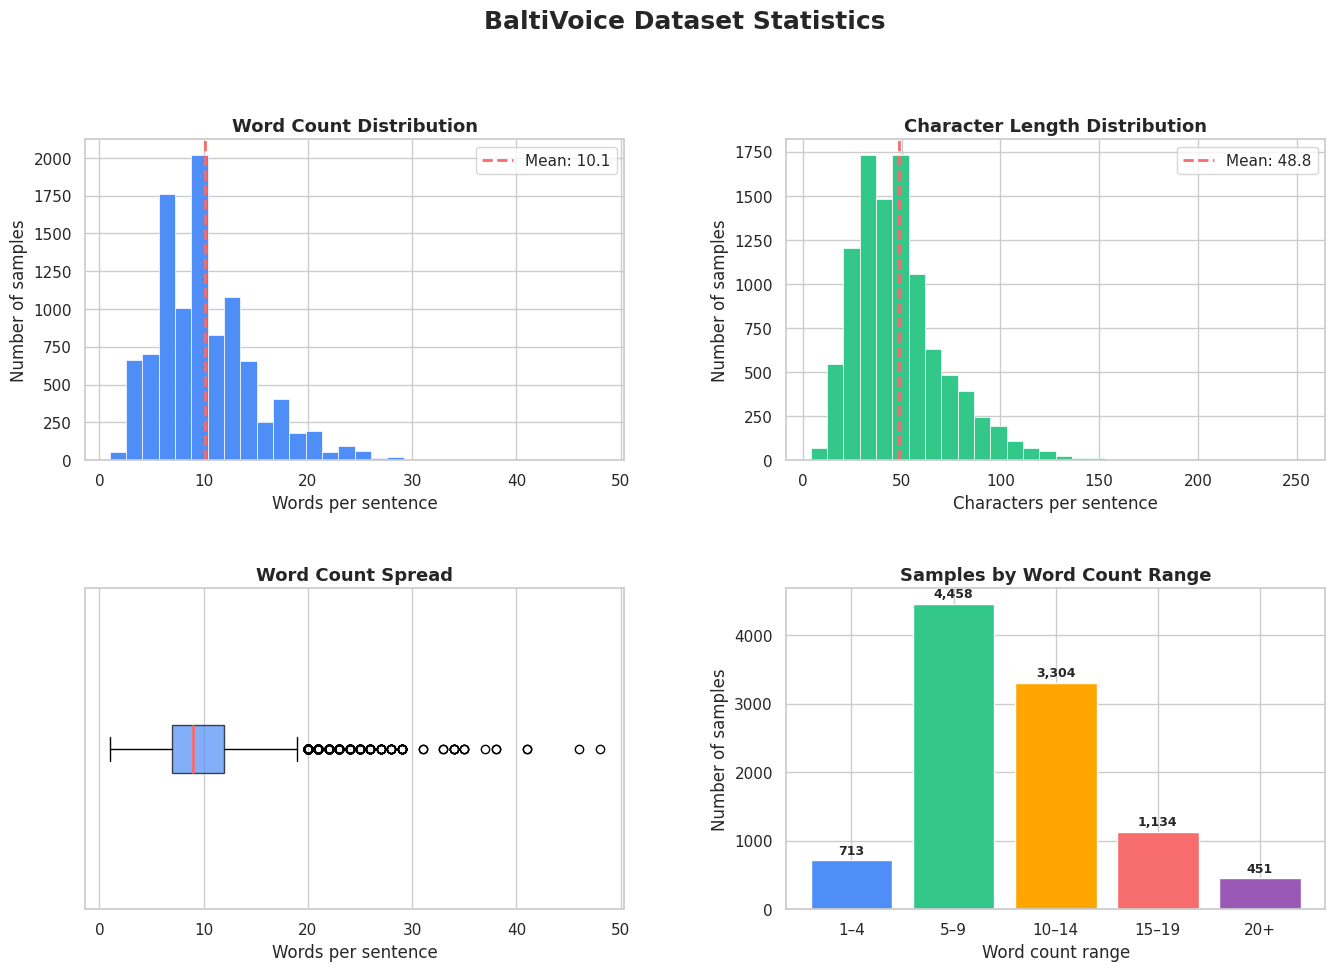

✅ Saved → dataset_statistics.png


In [11]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('BaltiVoice Dataset Statistics', fontsize=18, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

BLUE  = '#4F8EF7'
GREEN = '#34C78A'
RED   = '#F76C6C'

# ── Plot 1: Word count distribution ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['word_count'], bins=30, color=BLUE, edgecolor='white', linewidth=0.5)
ax1.axvline(df['word_count'].mean(), color=RED, linestyle='--', linewidth=2,
            label=f'Mean: {df["word_count"].mean():.1f}')
ax1.set_title('Word Count Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Words per sentence')
ax1.set_ylabel('Number of samples')
ax1.legend()

# ── Plot 2: Character length distribution ────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df['char_len'], bins=30, color=GREEN, edgecolor='white', linewidth=0.5)
ax2.axvline(df['char_len'].mean(), color=RED, linestyle='--', linewidth=2,
            label=f'Mean: {df["char_len"].mean():.1f}')
ax2.set_title('Character Length Distribution', fontsize=13, fontweight='bold')
ax2.set_xlabel('Characters per sentence')
ax2.set_ylabel('Number of samples')
ax2.legend()

# ── Plot 3: Word count boxplot ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
bp = ax3.boxplot(df['word_count'], vert=False, patch_artist=True,
                 boxprops=dict(facecolor=BLUE, alpha=0.7),
                 medianprops=dict(color=RED, linewidth=2))
ax3.set_title('Word Count Spread', fontsize=13, fontweight='bold')
ax3.set_xlabel('Words per sentence')
ax3.set_yticks([])

# ── Plot 4: Sentence count summary bar ──────────────────────
ax4 = fig.add_subplot(gs[1, 1])
bins  = [1, 5, 10, 15, 20, 50]
labels= ['1–4', '5–9', '10–14', '15–19', '20+']
counts= pd.cut(df['word_count'], bins=bins, labels=labels, right=False).value_counts().sort_index()
bars  = ax4.bar(counts.index, counts.values, color=[BLUE, GREEN, '#FFA500', RED, '#9B59B6'],
                edgecolor='white')
ax4.set_title('Samples by Word Count Range', fontsize=13, fontweight='bold')
ax4.set_xlabel('Word count range')
ax4.set_ylabel('Number of samples')
for bar, val in zip(bars, counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.savefig(f'{OUTPUT_DIR}/dataset_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → dataset_statistics.png')

---
## 4. Sample Sentences

A look at 10 random sentences from the dataset. The text is written in **Nastaliq script** — the Arabic-based writing system used for Balti.

In [13]:
# Display random sample sentences
sample = df[['sentence', 'word_count', 'char_len']].sample(10, random_state=7)
sample = sample.reset_index(drop=True)
sample.index += 1
sample.columns = ['Sentence (Balti)', 'Words', 'Chars']

print('Sample Sentences from BaltiVoice Dataset')
print('=' * 70)
for i, row in sample.iterrows():
    print(f"  {i:2}. {row['Sentence (Balti)']}")
    print(f"      [{row['Words']} words | {row['Chars']} chars]")
    print()

Sample Sentences from BaltiVoice Dataset
   1. تا بہرام گول بادشاہ نہ ن٘ا بر بید
      [8 words | 33 chars]

   2. یو خسامین نا ژھن نیما نوید یانگنہ نا چا تھوکپا مید
      [11 words | 50 chars]

   3. زیربا نہ مو سی زیرس، ”ن٘ا لیگسی رگشہ یودپا
      [9 words | 42 chars]

   4. بِلو دیکھہ کھورین دُوکس
      [4 words | 23 chars]

   5. عطر بطر سکُوس جُو
      [4 words | 17 chars]

   6. تا کھو بادشی کَھرِنگ چِہ بیا سونگس
      [7 words | 34 chars]

   7. ہِش سا فیونگنہ سنینگ پیکہ لجید اونگمی اِن
      [8 words | 41 chars]

   8. تا اومو تازہ کھڈس نہ ن٘ا صحیح سلامت یودپی اِن ن٘ا لوقسے اونگمی اِن
      [14 words | 66 chars]

   9. اے کھوے وزیر پو اِن
      [5 words | 19 chars]

  10. دس تھونگفو دوسے بین چی آشی دوسا داسے سونگ
      [9 words | 41 chars]



In [14]:
# Shortest and longest sentences
print('📏 SHORTEST SENTENCES')
print('-' * 50)
for _, row in df.nsmallest(3, 'word_count')[['sentence', 'word_count']].iterrows():
    print(f'  ({row["word_count"]} words) {row["sentence"]}')

print()
print('📐 LONGEST SENTENCES')
print('-' * 50)
for _, row in df.nlargest(3, 'word_count')[['sentence', 'word_count']].iterrows():
    print(f'  ({row["word_count"]} words) {row["sentence"]}')

📏 SHORTEST SENTENCES
--------------------------------------------------
  (1 words) ۔۔۔۔
  (1 words) ”میدپا”
  (1 words) ”میدپا”

📐 LONGEST SENTENCES
--------------------------------------------------
  (48 words) دینگ سن٘یالبا نہ کھوانگ لہ خسمس، رُومی بادشی بُو لہ، اُوہُوں، تھیب کھب ہلتُور، سنب ہلتُور بیاسے دُوکپا نہ می دُونُو نہ سہ ملا تھونگ شِشِک بیانگ زیرے نہ ہسکے کھہ لنگسے گو بو سترانگسے، کھاچھُو،سناچھُو چنگ سہ میدپا بیاسے سق سق رے، کھم سنگ رے بیاسے بیُونگس
  (46 words) گیوخسپا نہ بادشی بُو نہ نِ٘یسکا ہلژخمہ بخمے کُھورے بادشی دُوکسَکھی کھہ اونگسے، فاتحہ باتحے بیاسے ہلژخمہ بخمونگ بگوسے تنگسے نہ بادشی بُو سی زیرس، ”یلے بوا کسل دِینے می چِک اونگسے کھو سی زیرید، ’کھون٘ی اتو سی یری شِدیا خسیری کیالبُوی چِک یقسے یود لو
  (41 words) ”گوانہ یری ستونگ رگُو ہرمق گنگمہ دی جقمہ نِ٘یشُو ہرژقچِک پو گنگمہ سکیُورید نہ سکیُور مید نہ ن٘یا کِھری کَھر زدونگ لہ مے تان٘ید زیرین دُوکسے نہ ہسکے ہرژقچِک گنگمی اِنپا، دیُو نہ ینگ چِک اونگسے نہ دے ہرمق گنگمہ ردبس


---
## 5. Audio Duration Analysis

We measure the duration of a random sample of 500 audio clips to estimate total dataset hours and understand the distribution of clip lengths.

In [15]:
sample_n  = 500
sample_df = df.sample(sample_n, random_state=42)
durations = []

for _, row in tqdm(sample_df.iterrows(), total=sample_n, desc='Measuring durations'):
    try:
        durations.append(librosa.get_duration(path=row['full_path']))
    except Exception:
        pass

durations = np.array(durations)
est_hours = (durations.mean() * len(df)) / 3600

print('=' * 50)
print('     AUDIO DURATION STATISTICS')
print('=' * 50)
print(f'  Sampled clips     : {len(durations):,}')
print(f'  Min duration      : {durations.min():.2f}s')
print(f'  Max duration      : {durations.max():.2f}s')
print(f'  Mean duration     : {durations.mean():.2f}s')
print(f'  Median duration   : {np.median(durations):.2f}s')
print(f'  Std deviation     : {durations.std():.2f}s')
print(f'  ─────────────────────────────')
print(f'  Total clips       : {len(df):,}')
print(f'  Estimated hours   : {est_hours:.1f} hours')
print('=' * 50)

Measuring durations: 100%|██████████| 500/500 [00:04<00:00, 100.89it/s]

     AUDIO DURATION STATISTICS
  Sampled clips     : 500
  Min duration      : 1.55s
  Max duration      : 14.94s
  Mean duration     : 6.00s
  Median duration   : 5.58s
  Std deviation     : 2.41s
  ─────────────────────────────
  Total clips       : 10,060
  Estimated hours   : 16.8 hours


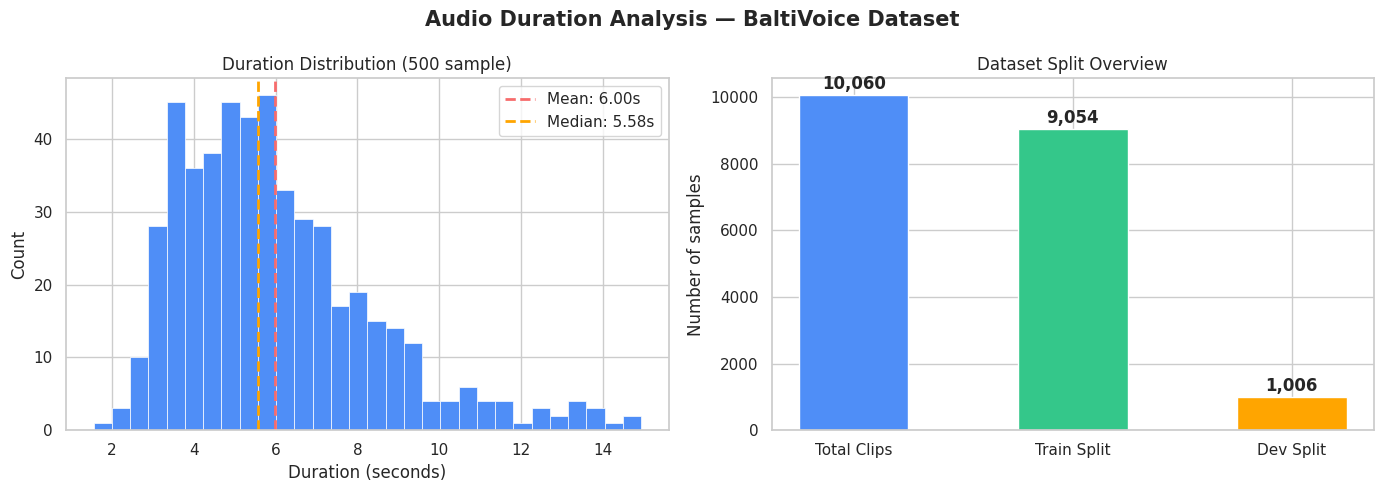

✅ Saved → duration_analysis.png
📦 Total dataset: ~16.8 hours of Balti speech


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Audio Duration Analysis — BaltiVoice Dataset', fontsize=15, fontweight='bold')

# ── Histogram ────────────────────────────────────────────────
axes[0].hist(durations, bins=30, color='#4F8EF7', edgecolor='white', linewidth=0.5)
axes[0].axvline(durations.mean(), color='#F76C6C', linestyle='--', linewidth=2,
                label=f'Mean: {durations.mean():.2f}s')
axes[0].axvline(np.median(durations), color='#FFA500', linestyle='--', linewidth=2,
                label=f'Median: {np.median(durations):.2f}s')
axes[0].set_title('Duration Distribution (500 sample)', fontsize=12)
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].legend()

# ── Dataset summary bar ──────────────────────────────────────
categories = ['Total Clips', 'Train Split', 'Dev Split']
values     = [len(df), int(len(df)*0.9), int(len(df)*0.1)]
colors     = ['#4F8EF7', '#34C78A', '#FFA500']
bars       = axes[1].bar(categories, values, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Dataset Split Overview', fontsize=12)
axes[1].set_ylabel('Number of samples')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → duration_analysis.png')
print(f'📦 Total dataset: ~{est_hours:.1f} hours of Balti speech')

---
## 6. Train / Dev Split

We remove sentences with fewer than 2 words (too short for meaningful ASR training), then split 90/10 into train and validation sets.

In [ ]:
df_clean = df[df['word_count'] >= 2].reset_index(drop=True)
removed  = len(df) - len(df_clean)
print(f'Removed {removed} samples with < 2 words')

train_df, dev_df = train_test_split(df_clean, test_size=0.10, random_state=42)

train_df.to_csv(f'{OUTPUT_DIR}/train.tsv', sep='\t', index=False)
dev_df.to_csv(f'{OUTPUT_DIR}/dev.tsv',   sep='\t', index=False)

print()
print('=' * 40)
print('       DATASET SPLITS')
print('=' * 40)
print(f'  Total (clean) : {len(df_clean):,}')
print(f'  Train (90%)   : {len(train_df):,}')
print(f'  Dev   (10%)   : {len(dev_df):,}')
print('=' * 40)
print('✅ Saved train.tsv and dev.tsv')

---
## 7. Model & Preprocessing Setup

We use **OpenAI Whisper-small** as our base model — a 244M parameter multilingual ASR model. Since Balti uses Nastaliq script (same as Urdu), we initialise the tokenizer with `language='urdu'` as the closest supported script.

**Pipeline:**
1. `WhisperFeatureExtractor` — converts raw audio → log-mel spectrograms
2. `WhisperTokenizer` — converts Balti text → token IDs
3. `DataCollator` — pads batches for training
4. `WER metric` — evaluates transcription accuracy

In [ ]:
from datasets import load_dataset, Audio
from transformers import WhisperFeatureExtractor, WhisperTokenizer, WhisperProcessor

MODEL_NAME = 'openai/whisper-small'

feature_extractor = WhisperFeatureExtractor.from_pretrained(MODEL_NAME)
tokenizer  = WhisperTokenizer.from_pretrained(MODEL_NAME, language='urdu', task='transcribe')
processor  = WhisperProcessor.from_pretrained(MODEL_NAME, language='urdu', task='transcribe')

print(f'✅ Processor loaded')
print(f'   Model          : {MODEL_NAME}')
print(f'   Language       : Urdu (Nastaliq script — same as Balti)')
print(f'   Task           : transcribe')
print(f'   Sampling rate  : {feature_extractor.sampling_rate} Hz')

In [ ]:
# Load dataset from HuggingFace Hub
dataset = load_dataset('mohdali1/baltivoice-asr', token=NEW_TOKEN)
dataset = dataset.cast_column('audio', Audio(sampling_rate=16000))
print('✅ Dataset loaded from HuggingFace Hub')
print(dataset)

In [ ]:
# Preprocessing: audio → features, text → token IDs
def prepare_dataset(batch):
    audio = batch['audio']
    batch['input_features'] = feature_extractor(
        audio['array'], sampling_rate=audio['sampling_rate']
    ).input_features[0]
    batch['labels'] = tokenizer(batch['sentence']).input_ids
    return batch

dataset = dataset.map(
    prepare_dataset,
    remove_columns=dataset.column_names['train'],
    num_proc=1
)
print('✅ Preprocessing complete')
print(dataset)

In [ ]:
import torch
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    """Pads audio features and label token sequences per batch."""
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]):
        input_features = [{'input_features': f['input_features']} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors='pt')

        label_features = [{'input_ids': f['labels']} for f in features]
        labels_batch   = self.processor.tokenizer.pad(label_features, return_tensors='pt')
        labels = labels_batch['input_ids'].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]
        batch['labels'] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)
print('✅ Data collator ready')

In [ ]:
import evaluate

# WER = Word Error Rate (lower is better)
# WER = (Substitutions + Deletions + Insertions) / Total Words × 100
metric = evaluate.load('wer')

def compute_metrics(pred):
    pred_ids  = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = tokenizer.pad_token_id
    pred_str  = tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    return {'wer': 100 * metric.compute(predictions=pred_str, references=label_str)}

print('✅ WER metric ready')
print('   WER = Word Error Rate (lower is better)')
print('   Target: < 35% for low-resource language')

---
## 8. Fine-tuning Whisper

We fine-tune `whisper-small` for **1000 steps** using the HuggingFace `Seq2SeqTrainer`.

| Hyperparameter | Value |
|---|---|
| Base model | openai/whisper-small |
| Batch size | 8 (+ 2 gradient accumulation = 16 effective) |
| Learning rate | 1e-5 |
| Warmup steps | 100 |
| Max steps | 1000 |
| Precision | fp16 |
| Evaluation | Every 250 steps |
| GPU | Tesla T4 (Google Colab) |

> ⏱️ **Expected training time: ~2 hours on T4 GPU**

In [ ]:
from transformers import (
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)
model.generation_config.language = 'urdu'
model.generation_config.task     = 'transcribe'
model.generation_config.forced_decoder_ids = None

training_args = Seq2SeqTrainingArguments(
    output_dir                  = f'{DATASET_ROOT}/whisper-balti',
    per_device_train_batch_size = 8,
    gradient_accumulation_steps = 2,
    learning_rate               = 1e-5,
    warmup_steps                = 100,
    max_steps                   = 1000,
    gradient_checkpointing      = True,
    fp16                        = True,
    eval_strategy               = 'steps',
    per_device_eval_batch_size  = 8,
    predict_with_generate       = True,
    generation_max_length       = 225,
    save_steps                  = 250,
    eval_steps                  = 250,
    logging_steps               = 25,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'wer',
    greater_is_better           = False,
    push_to_hub                 = False,
)

trainer = Seq2SeqTrainer(
    args             = training_args,
    model            = model,
    train_dataset    = dataset['train'],
    eval_dataset     = dataset['validation'],
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
    processing_class = processor.feature_extractor,
)

print('✅ Trainer ready — starting training...')
trainer.train()

---
## 9. Training Results

WER (Word Error Rate) dropped consistently throughout training, demonstrating effective learning on Balti — a language Whisper had never seen before.

Training Results Summary
 step  train_loss  val_loss   wer
  250      0.7905    0.4037 40.19
  500      0.5968    0.3208 33.37
  750      0.4542    0.2963 31.37
 1000      0.4652    0.2830 30.07

Final WER  : 30.07%
Total drop : 10.12 percentage points


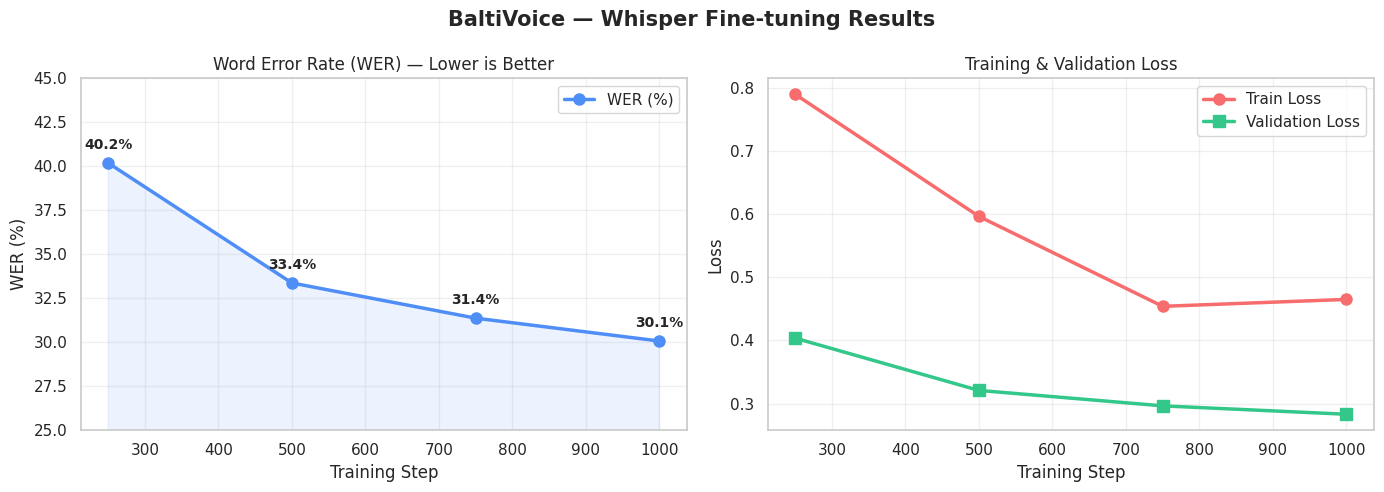

✅ Saved → training_results.png


In [12]:
# Training results
results = {
    'step'       : [250, 500, 750, 1000],
    'train_loss' : [0.7905, 0.5968, 0.4542, 0.4652],
    'val_loss'   : [0.4037, 0.3208, 0.2963, 0.2830],
    'wer'        : [40.19, 33.37, 31.37, 30.07],
}
results_df = pd.DataFrame(results)

print('Training Results Summary')
print('=' * 60)
print(results_df.to_string(index=False))
print('=' * 60)
print(f'\nFinal WER  : {results["wer"][-1]}%')
print(f'Total drop : {results["wer"][0] - results["wer"][-1]:.2f} percentage points')

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BaltiVoice — Whisper Fine-tuning Results', fontsize=15, fontweight='bold')

# WER curve
axes[0].plot(results['step'], results['wer'], 'o-', color='#4F8EF7',
             linewidth=2.5, markersize=8, label='WER (%)')
for x, y in zip(results['step'], results['wer']):
    axes[0].annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Word Error Rate (WER) — Lower is Better', fontsize=12)
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('WER (%)')
axes[0].set_ylim(25, 45)
axes[0].fill_between(results['step'], results['wer'], alpha=0.1, color='#4F8EF7')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curves
axes[1].plot(results['step'], results['train_loss'], 'o-', color='#F76C6C',
             linewidth=2.5, markersize=8, label='Train Loss')
axes[1].plot(results['step'], results['val_loss'],   's-', color='#34C78A',
             linewidth=2.5, markersize=8, label='Validation Loss')
axes[1].set_title('Training & Validation Loss', fontsize=12)
axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → training_results.png')

---
## 10. Push to HuggingFace Hub

We push both the fine-tuned model and processor to the HuggingFace Hub for public access and deployment.

In [ ]:
from huggingface_hub import HfApi

api = HfApi(token=NEW_TOKEN)

try:
    user = api.whoami()
    print(f'✅ Logged in as: {user["name"]}')
except Exception as e:
    print(f'❌ Login failed: {e}')
    raise

print('🚀 Pushing model to Hub... (2–5 mins)')
model.push_to_hub('mohdali1/whisper-small-balti',     token=NEW_TOKEN)
processor.push_to_hub('mohdali1/whisper-small-balti', token=NEW_TOKEN)

print()
print('=' * 60)
print('🎉 BaltiVoice ASR — Project Complete!')
print('=' * 60)
print('  📦 Dataset : https://huggingface.co/datasets/mohdali1/baltivoice-asr')
print('  🤖 Model   : https://huggingface.co/mohdali1/whisper-small-balti')
print('  🎙️  Demo    : https://huggingface.co/spaces/mohdali1/baltivoice-demo')
print('  📁 GitHub  : https://github.com/mohdali1/BaltiVoice-ASR')
print('=' * 60)
print('  Final WER  : 30.07%')
print('  Total data : 16.8 hours')
print('  Language   : Balti (bft) — first public ASR system')
print('=' * 60)

In [17]:
# Run this after the chart cells to confirm files saved correctly
import os

files = [
    'dataset_statistics.png',
    'duration_analysis.png',
    'training_results.png'
]

OUTPUT_DIR = '/content/drive/MyDrive/Balti Voice Model/baltivoice_processed'

for f in files:
    path = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(path) if os.path.exists(path) else 0
    status = f'✅ {size/1024:.0f} KB' if size else '❌ Missing'
    print(f'{f}: {status}')

dataset_statistics.png: ✅ 143 KB
duration_analysis.png: ✅ 87 KB
training_results.png: ✅ 117 KB
